# White Paper - MTH 9899 Final Project

- Tian Tian, tian.tian.baruchmfe@gmail.com
- Chaithanya Pakala, chaithanya.pakala.baruchmfe@gmail.com
- Baruch MFE cohort 2025-2026

## 1. Project Scope and Research Protocol

### 1.1 Scope of this draft

- The submitted `submission_files/` tree is treated as the source of truth for implemented behavior.
- This draft fully documents both the feature engineering pipeline and the model training, hyperparameter selection, and prediction-side validation.
- All five required models have been trained, evaluated on the 2014 validation year, retrained on 2010–2014, and evaluated on the true 2015 OOS year.

### 1.2 Research boundary

- All feature design, feature-parameter tuning, and cross-feature redundancy pruning were performed using only the first 4 years of the provided dataset (2010–2013).
- The year 2014 was kept strictly out of sample during feature research and hyperparameter tuning.
- 2015 data from `oos_data/` was used only for the final true OOS evaluation, after all modelling decisions were frozen.
- We do not use raw calendar date as a predictive feature. All signals are defined per `(Date, Id)` from intraday paths or lagged daily inputs.

### 1.3 Current pipeline status

- Feature generation is fully implemented in `submission_files/feature_src/`.
- The PDF-style command-line wrapper is implemented in `submission_files/main.py`.
- Mode 2 prediction generation is implemented in `submission_files/model_src/model_predictor.py`. It loads five fitted model artefacts from `model_src/saved_models/`, applies the same three-stage feature transformation used during training (5-MAD clipping → z-score normalization → cross-sectional rank normalization), runs the Ens-5 diversity-weighted ensemble, and writes one `predictions_YYYYMMDD.csv` per date.

## 2. Submitted Pipeline and Code Status

### 2.1 Command-line interface

The submitted `main.py` exposes the required options from the assignment:

- `-i`: input directory (raw data for Mode 1; feature CSV directory for Mode 2)
- `-o`: output directory
- `-p`: model directory for Mode 2 (contains `.joblib` and `.pt` artefacts)
- `-s`: start date in `YYYYMMDD`
- `-e`: end date in `YYYYMMDD`
- `-m`: mode selector (1 = features, 2 = predictions)

### 2.2 Mode 1: feature generation

Mode 1 expects a raw data root containing `intraday_data/` and `daily_data/` folders. It:

1. Loads and cleans intraday data (schema check, cumulative-to-incremental conversion, NaN removal).
2. Loads lagged daily panel data (adjusted prices, `EST_VOL`, `MDV_63`).
3. Builds the full feature matrix via `feature_src.feature_engineering.build_daily_dataset`.
4. Filters rows to `[start_date, end_date]` and writes one `features_YYYYMMDD.csv` per date to the output directory.

Output files contain all 18 feature columns plus `Id` and `Date`. The target is excluded from Mode 1 output (`include_target=False`).

### 2.3 Mode 2: prediction generation

Mode 2 reads feature CSVs written by Mode 1 and outputs `predictions_YYYYMMDD.csv` files with columns `Date`, `Time`, `Id`, `Pred`.

The prediction pipeline in `model_src/model_predictor.py`:

1. Loads transformation artefacts (`clip_params.joblib`, `norm_params.joblib`) and five fitted models (`ridge.joblib`, `rf.joblib`, `xgb.joblib`, `mlp.joblib`, `resmlp_state.pt`) from `model_dir`.
2. For each date file, applies the same three-stage transformation used during training: 5-MAD clipping with train-derived bounds → stage-1 z-score with train mean/std → cross-sectional rank normalization (per-date, applied to the incoming date's stocks only).
3. Generates predictions from all five models and combines them using the Ens-5 diversity-weighted ensemble weights saved in `ensemble_weights.joblib`.
4. Writes `predictions_YYYYMMDD.csv` with `Time = "15:30"` for each date.

## 3. Target Construction and Data Alignment

### 3.1 Prediction timestamp and target definition

Predictions are made at `15:30` on date $T$. The submitted feature code implements the target as

$$
\text{target}(T, i) = \text{ResidReturn}(T, 16{:}00, i) + \text{CumReturnResid}(T_{\text{next}}, 15{:}30, i).
$$

This has the following interpretation:

- `ResidReturn(T, 16:00)` is the incremental residual return from `15:30` to `16:00` on the same day.
- `CumReturnResid(T_next, 15:30)` is the cumulative residual return from the prior close through `15:30` on the next trading session.
- The next session is inferred from the observed trading calendar in the data, so weekends and holidays are handled through actual trading dates rather than a fixed one-day shift.

### 3.2 Daily feature alignment

Daily features are computed on $T-1$ or earlier daily data only. During the merge step, the daily feature panel is shifted forward to the next intraday trading day using the intraday trading calendar so that lagged daily information aligns with the prediction date $T$.

### 3.3 PDF recommendations not yet implemented in the submitted feature code

The PDF recommends several modeling choices that are not yet present in the submitted feature-side pipeline:

- clipping the target before fitting,
- normalizing the target by `EST_VOL` before fitting and scaling predictions back into return space afterward,
- choosing and applying sample weights during model training.


## 4. Data Cleaning, Preprocessing, and Leakage Safeguards

### 4.1 Intraday integrity checks

The submitted intraday loader enforces a consistent schema and time structure through `schema_check.py`:

- expected columns are `Date`, `Time`, `Id`, `CumReturnResid`, `CumReturnRaw`, and `CumVolume`,
- expected dtypes are checked and mismatches are surfaced as warnings,
- each stock-day is expected to contain `26` rows from `09:45` through `16:00`,
- file size is checked against `expected_lines = 13000` as a warning-based sanity check.

### 4.2 Converting cumulative fields into incremental series

`missing_value_drop.convert_cum_to_increment(...)` converts cumulative intraday fields into bar-level increments by `(Id, calendar date)`:

- `ResidReturn` is the within-day difference of `CumReturnResid`,
- `RawReturn` is the within-day difference of `CumReturnRaw`,
- `Volume` is the within-day difference of `CumVolume`.

For the first bar of each stock-day, the submitted pipeline keeps the cumulative value itself as that bar's increment. This matches the data note that the `09:45` snapshot already includes the overnight move from the prior close.

### 4.3 Missing-value handling and timestamp filtering

After incremental conversion, the submitted pipeline applies two hard filters:

- `drop_id_with_nan_by_trading_day(...)` removes an entire `(trading day, Id)` block if any row for that stock on that day contains a missing value,
- timestamps are removed if all stocks have `RawReturn == 0` at that timestamp.

A research-side sanity check also observed cases with `Volume == 0` but non-zero return. Those observations are useful to record, but the submitted pipeline does not currently add an extra exclusion rule for them.

### 4.4 Daily panel preprocessing

`daily_data_loader.load_daily_data(...)` loads the daily `dat.*.csv` files and builds an adjusted daily panel:

- `OpenAdj`, `HighAdj`, `LowAdj`, and `CloseAdj` are built from raw prices and `PxAdjFactor`,
- `VolumeAdj` is built from `Volume` and `SharesAdjFactor`,
- the panel retains fields such as `EST_VOL`, `MDV_63`, and `FREE_FLOAT_PERCENTAGE` for later modeling or feature use.

### 4.5 MAD-based robustness filter

After intraday features, target, and lagged daily features are joined, the submitted pipeline applies a per-feature MAD filter whenever a feature has a `mad_filter` block in `features_config.json`.

- The filter is applied per `Id`.
- It uses an expanding median and an expanding MAD.
- The effective thresholds update every `update_freq_days` after `warmup_days`.
- Values outside the configured region are set to `0.0` rather than clipped.

Among the `18` enabled features, `14` use a MAD filter. The four enabled features without a MAD filter are `late_day_trend`, `closing_auction_participation_ratio`, `intraday_volume_concentration`, and `bollinger_band`.

### 4.6 Leakage controls

The submitted materials include an internal `leakage_smoke_test(...)`:

- the sample is split into early and late halves by date,
- future-date intraday fields are shuffled within each `Id`,
- the feature matrix is rebuilt,
- the code checks that an early safe window remains unchanged.
- this smoke test is available in the submitted materials, but `run_mode1(...)` currently calls the pipeline with `run_tests=False`, so it is not executed automatically during standard feature export.

This is a meaningful internal leakage check, but it is not the exact PDF-style harness described in the assignment. The PDF wording indicates that the instructors will perform a separate grader-side audit by rerunning Mode 1 with and without future raw files present in the input directory and checking that the exported features are identical. The internal smoke test should therefore be described as a self-check, not as the official leakage test from the PDF.


## 5. Feature Universe and Full List

### 5.1 Feature categories

The final submitted feature set contains `18` enabled features: `12` intraday features and `6` lagged daily features.

- **Intraday path-based features** summarize the same-day residual return path, volume path, or closing-auction behavior up to the `15:30` prediction cutoff.
- **Lagged daily features** summarize prior-day or multi-day price positioning, reversal, and momentum behavior from the adjusted daily panel.
- **Model input format** remains cross-sectional by `(Date, Id)`, but no raw date field is used directly as a feature.

### 5.2 How to read the MAD filter settings

The tables below list only features with `enabled: true` in `submit/feature_src/features_config.json`. The `MAD filter` column records the post-processing rule applied after raw feature construction.

In the submitted implementation, the gate is applied **per `Id`** with an expanding median and median absolute deviation (MAD). After the `warmup_days` period, the median and MAD are refreshed every `update_freq_days`; observations that do not satisfy the rule are set to `0.0` rather than dropped.

- `left_tail`: keep only values below $\mathrm{median} - \mathrm{mad\_scale} \times \mathrm{MAD}$.
- `right_tail`: keep only values above $\mathrm{median} + \mathrm{mad\_scale} \times \mathrm{MAD}$.
- `outside_both`: keep only values outside the symmetric band $\mathrm{median} \pm \mathrm{mad\_scale} \times \mathrm{MAD}$.
- `center`: keep only values inside the symmetric band $\mathrm{median} \pm \mathrm{mad\_scale} \times \mathrm{MAD}$.
- The numeric pattern `rule, mad_scale, update_freq_days/warmup_days` tells the reader how wide the gate is and how often the reference band is refreshed.
- If the table says `none`, the feature is passed through without this additional MAD gate.

### 5.3 Enabled intraday features

| Feature | Construction | MAD filter |
|---|---|---|
| `intraday_momentum` | sum of `ResidReturn` from `10:00` to `15:30` | `left_tail, 4, 21/21` |
| `intraday_reversal` | sum `13:30-15:30` minus sum `09:45-13:29` of `ResidReturn` | `outside_both, 4, 21/21` |
| `resid_vol` | standard deviation of `ResidReturn` from `09:45` to `15:30` | `left_tail, 4, 21/21` |
| `late_day_trend` | `15:00-15:30` residual-return sum minus its 10-day rolling mean | `none` |
| `intraday_skewness` | skewness of `ResidReturn` from `09:45` to `15:30` | `left_tail, 4, 21/21` |
| `early_late_volume_mix` | `(V_late - V_early) / V_total` using `CumVolume` with split time `13:00` | `left_tail, 4, 21/21` |
| `return_volume_corr` | correlation between `ResidReturn` and `Volume` over `11:00-15:00` | `right_tail, 4, 21/21` |
| `lag1_autocorr` | lag-1 autocorrelation of `ResidReturn` from `10:00` to `15:30` | `left_tail, 4, 21/21` |
| `closing_auction_participation_ratio` | `(CumVol_16:00 - CumVol_15:30) / CumVol_15:30` | `none` |
| `intraday_kurtosis` | excess kurtosis of `ResidReturn` from `09:45` to `15:30` | `right_tail, 4, 21/21` |
| `intraday_vwap_deviation` | `(close_proxy - VWAP_proxy) / VWAP_proxy` from `CumReturnResid` and `Volume` | `left_tail, 4, 21/21` |
| `intraday_volume_concentration` | Herfindahl index of intraday `Volume` concentration | `none` |

### 5.4 Enabled daily features

| Feature | Construction | MAD filter |
|---|---|---|
| `mean_reversion_ma` | `CloseAdj / SMA_120 - 1` | `outside_both, 4, 21/21` |
| `short_term_reversal` | 1-day close-to-close return | `center, 3, 21/21` |
| `bollinger_band` | `(CloseAdj - SMA_5) / rolling_std_5` | `none` |
| `raw_momentum` | 5-day cumulative return from the lagged daily close series | `outside_both, 4, 21/21` |
| `open_to_close_return` | `(CloseAdj - OpenAdj) / OpenAdj` on the lagged daily bar | `right_tail, 4, 21/21` |
| `close_position_daily_range` | `(2 * CloseAdj - HighAdj - LowAdj) / (HighAdj - LowAdj)` | `right_tail, 2, 21/21` |


## 6. Feature Parameter Search, Selection, and Redundancy Control

### 6.1 Grid-search framework in `feature_lab/`

Feature parameters were tuned in the dedicated `feature_lab/` workflow rather than by editing one feature at a time by hand.

- Each candidate feature is defined by a JSON file under `feature_lab/definitions/`.
- A definition contains a base formula plus either a `param_grid` or explicit `param_combos`.
- `feature_lab_generator.expand_grid(...)` expands the Cartesian product of candidate parameter values.
- `generate_variants(...)` computes all parameter variants in batch using the same core feature-engineering functions used by the main project.
- `feature_lab_runner.py` caches the raw intraday and daily data, builds the target once, generates all variants for one definition, aligns daily variants to the next trading day, and evaluates every parameter combination on the same sample.

### 6.2 Diagnostics used to choose feature parameters

Feature parameters were not chosen by simply taking the single best point estimate. The selection process combines several diagnostics from `feature_lab_evaluator.py`, `feature_lab_reporter.py`, and `src/feature_evaluation.py`:

- daily Pearson IC,
- daily Spearman IC,
- mean IC, IC standard deviation, IR, and a simple t-statistic,
- 10-bin feature-vs-target plots with standard errors,
- the same 10-bin plots after 5-MAD winsorization,
- parameter heatmaps when the grid has two dimensions,
- marginal parameter sensitivity plots with error bars,
- time-split robustness checks between the first and second halves of the sample,
- rolling IC plots for stability over time.

The report generator sorts variants by Pearson IR and combines summary tables with diagnostic plots, so parameter tuning is based on both ranking metrics and visual robustness checks.

### 6.3 Selection rule for the final feature parameters

The final parameter choice for each feature family follows the same general logic:

- run a grid search over all candidate parameter combinations,
- compare the full set of variants rather than only the top-ranked one,
- prefer parameter regions with a clear and stable trend over isolated local optima,
- use the 10-bin plots together with standard errors to decide whether the apparent best point is statistically meaningful or just noise,
- use IC and IR jointly so that both signal strength and signal consistency matter,
- when several combinations are close, prefer the more stable and interpretable setting rather than the noisiest peak.

In practice, this feature-parameter search is the core of the feature-selection workflow.

### 6.4 Cross-feature pruning after parameter tuning

After one final parameter setting is chosen for each feature family, `notebook/feature_evaluation.ipynb` is used to inspect the entire selected feature set together rather than one feature at a time.

That notebook performs the following checks:

- Phase 1: NaN ratios and feature coverage,
- Phase 2: Pearson and Spearman IC summaries plus 30-day rolling Spearman IC,
- Phase 3: 10-bin plots, both raw and 5-MAD winsorized,
- Phase 4: monthly feature distribution time series,
- Phase 5: Pearson correlation matrix across the selected features.

The last step is used to remove redundant signals. Highly correlated feature pairs are reviewed together, and one of the two is removed when they are too similar. The notebook explicitly highlights pairs with `|r| > 0.5`, which serves as the first-pass redundancy screen before the final enabled set is frozen.


## 7. Feature Importance and Most Significant Features

### 7.1 Required by the assignment

The white paper is required to include feature importance using a permutation-style method such as MDA or MDI, and to include bin plots for the most significant features against the target variable.

### 7.2 Current status

The final **model-dependent** importance requirement is still pending because the submitted materials do not yet contain a fitted final learner or an MDA routine tied to that learner.

### 7.3 What is available now

Two feature-side diagnostics can already be documented without the final model:

- a ranking proxy based on daily cross-sectional IC on the research sample, and
- **4-bin** feature-vs-target plots using a **qcut-like equal-frequency** binning rule.

The notebook code below calls a thin wrapper in `submit/whitepaper_notebook.py`, which delegates the plotting logic to `submit/feature_src/report_visualizations.py`. The underlying qcut-like routine breaks ties by stable ranking before binning, so the plot still retains exactly four bins when the sample size is sufficient. This keeps the feature-side presentation aligned with the assignment's binning convention while remaining robust to the clipped feature distributions used in this project.


,spearman_mean_ic,spearman_ir,pearson_mean_ic,pearson_ir
feature,,,,
closing_auction_participation_ratio,0.011615,0.231507,0.009402,0.164213
resid_vol,0.011082,0.205181,0.011087,0.119071
late_day_trend,0.010356,0.191249,0.012413,0.148303
short_term_reversal,0.009012,0.165324,0.008128,0.116077
bollinger_band,0.008806,0.162536,0.005823,0.110704
intraday_vwap_deviation,0.008436,0.155497,0.010376,0.114024
intraday_momentum,0.008228,0.154067,0.010992,0.118186
intraday_volume_concentration,0.007109,0.147089,0.004350,0.079515
intraday_skewness,0.006627,0.135925,0.006867,0.129373


Training observations: 500,616
Top features by |mean daily Spearman IC|: ['closing_auction_participation_ratio', 'resid_vol', 'late_day_trend', 'short_term_reversal', 'bollinger_band', 'intraday_vwap_deviation']
Saved bin-plot figure to: E:\Baruch\MLproject\submit\figures\top_feature_bin_plots_train_4bins.png


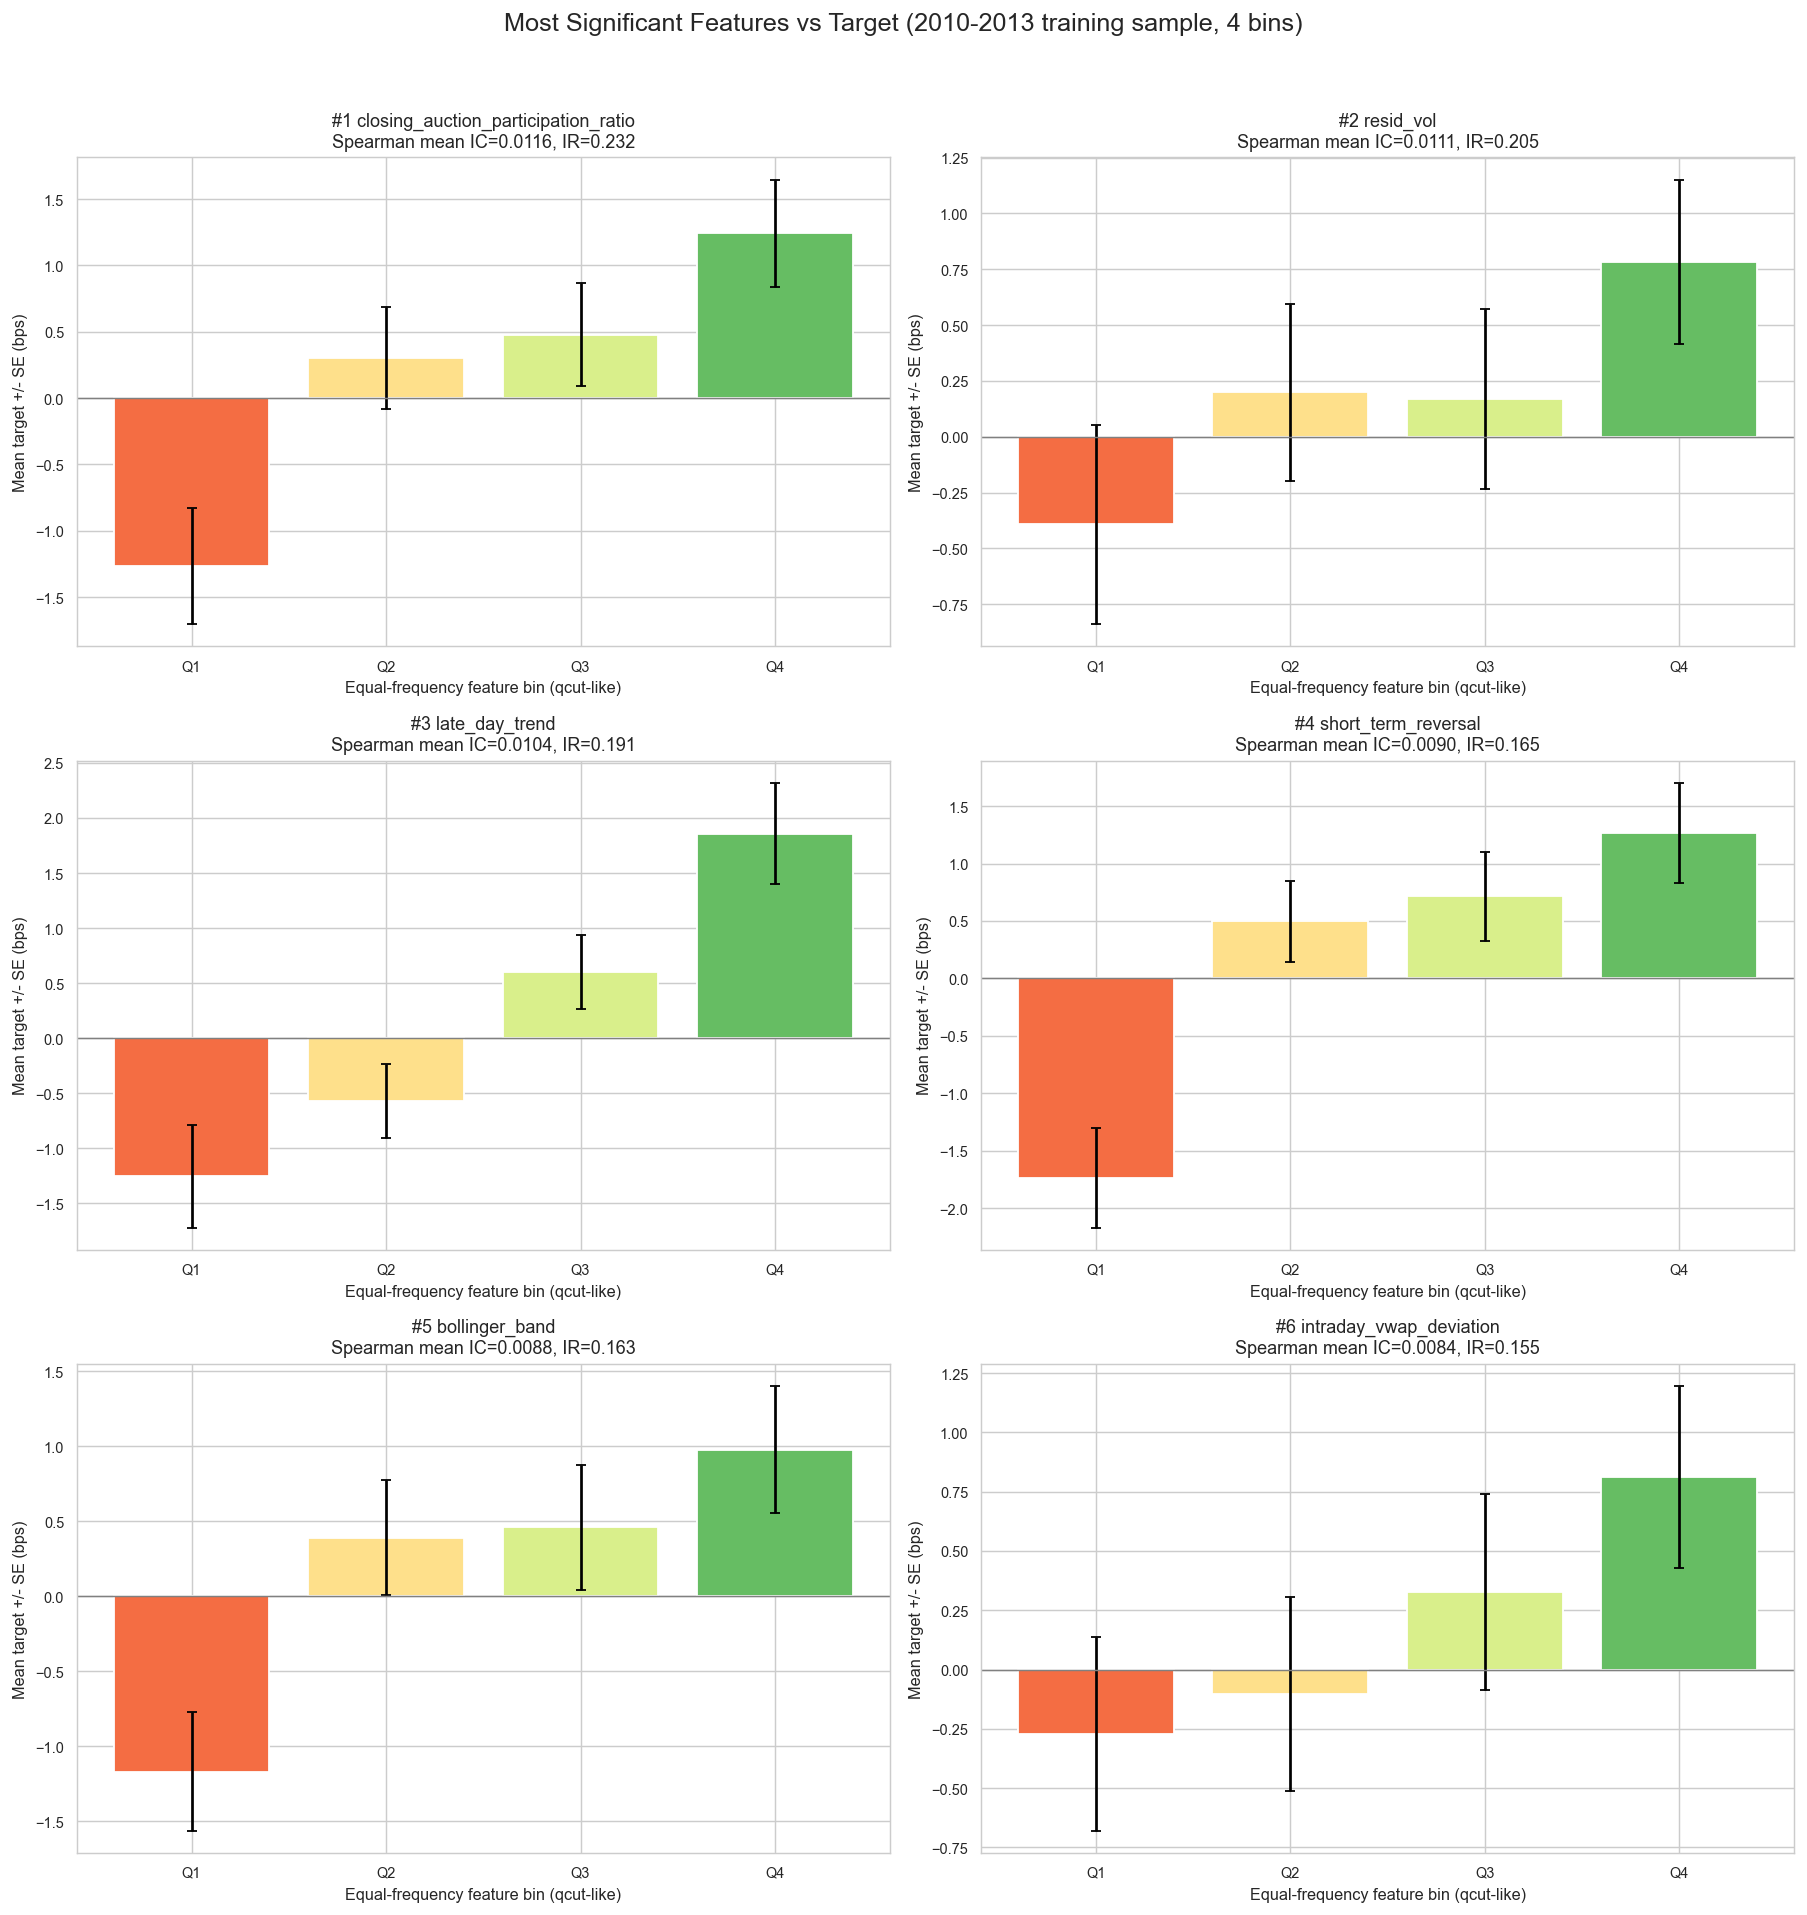

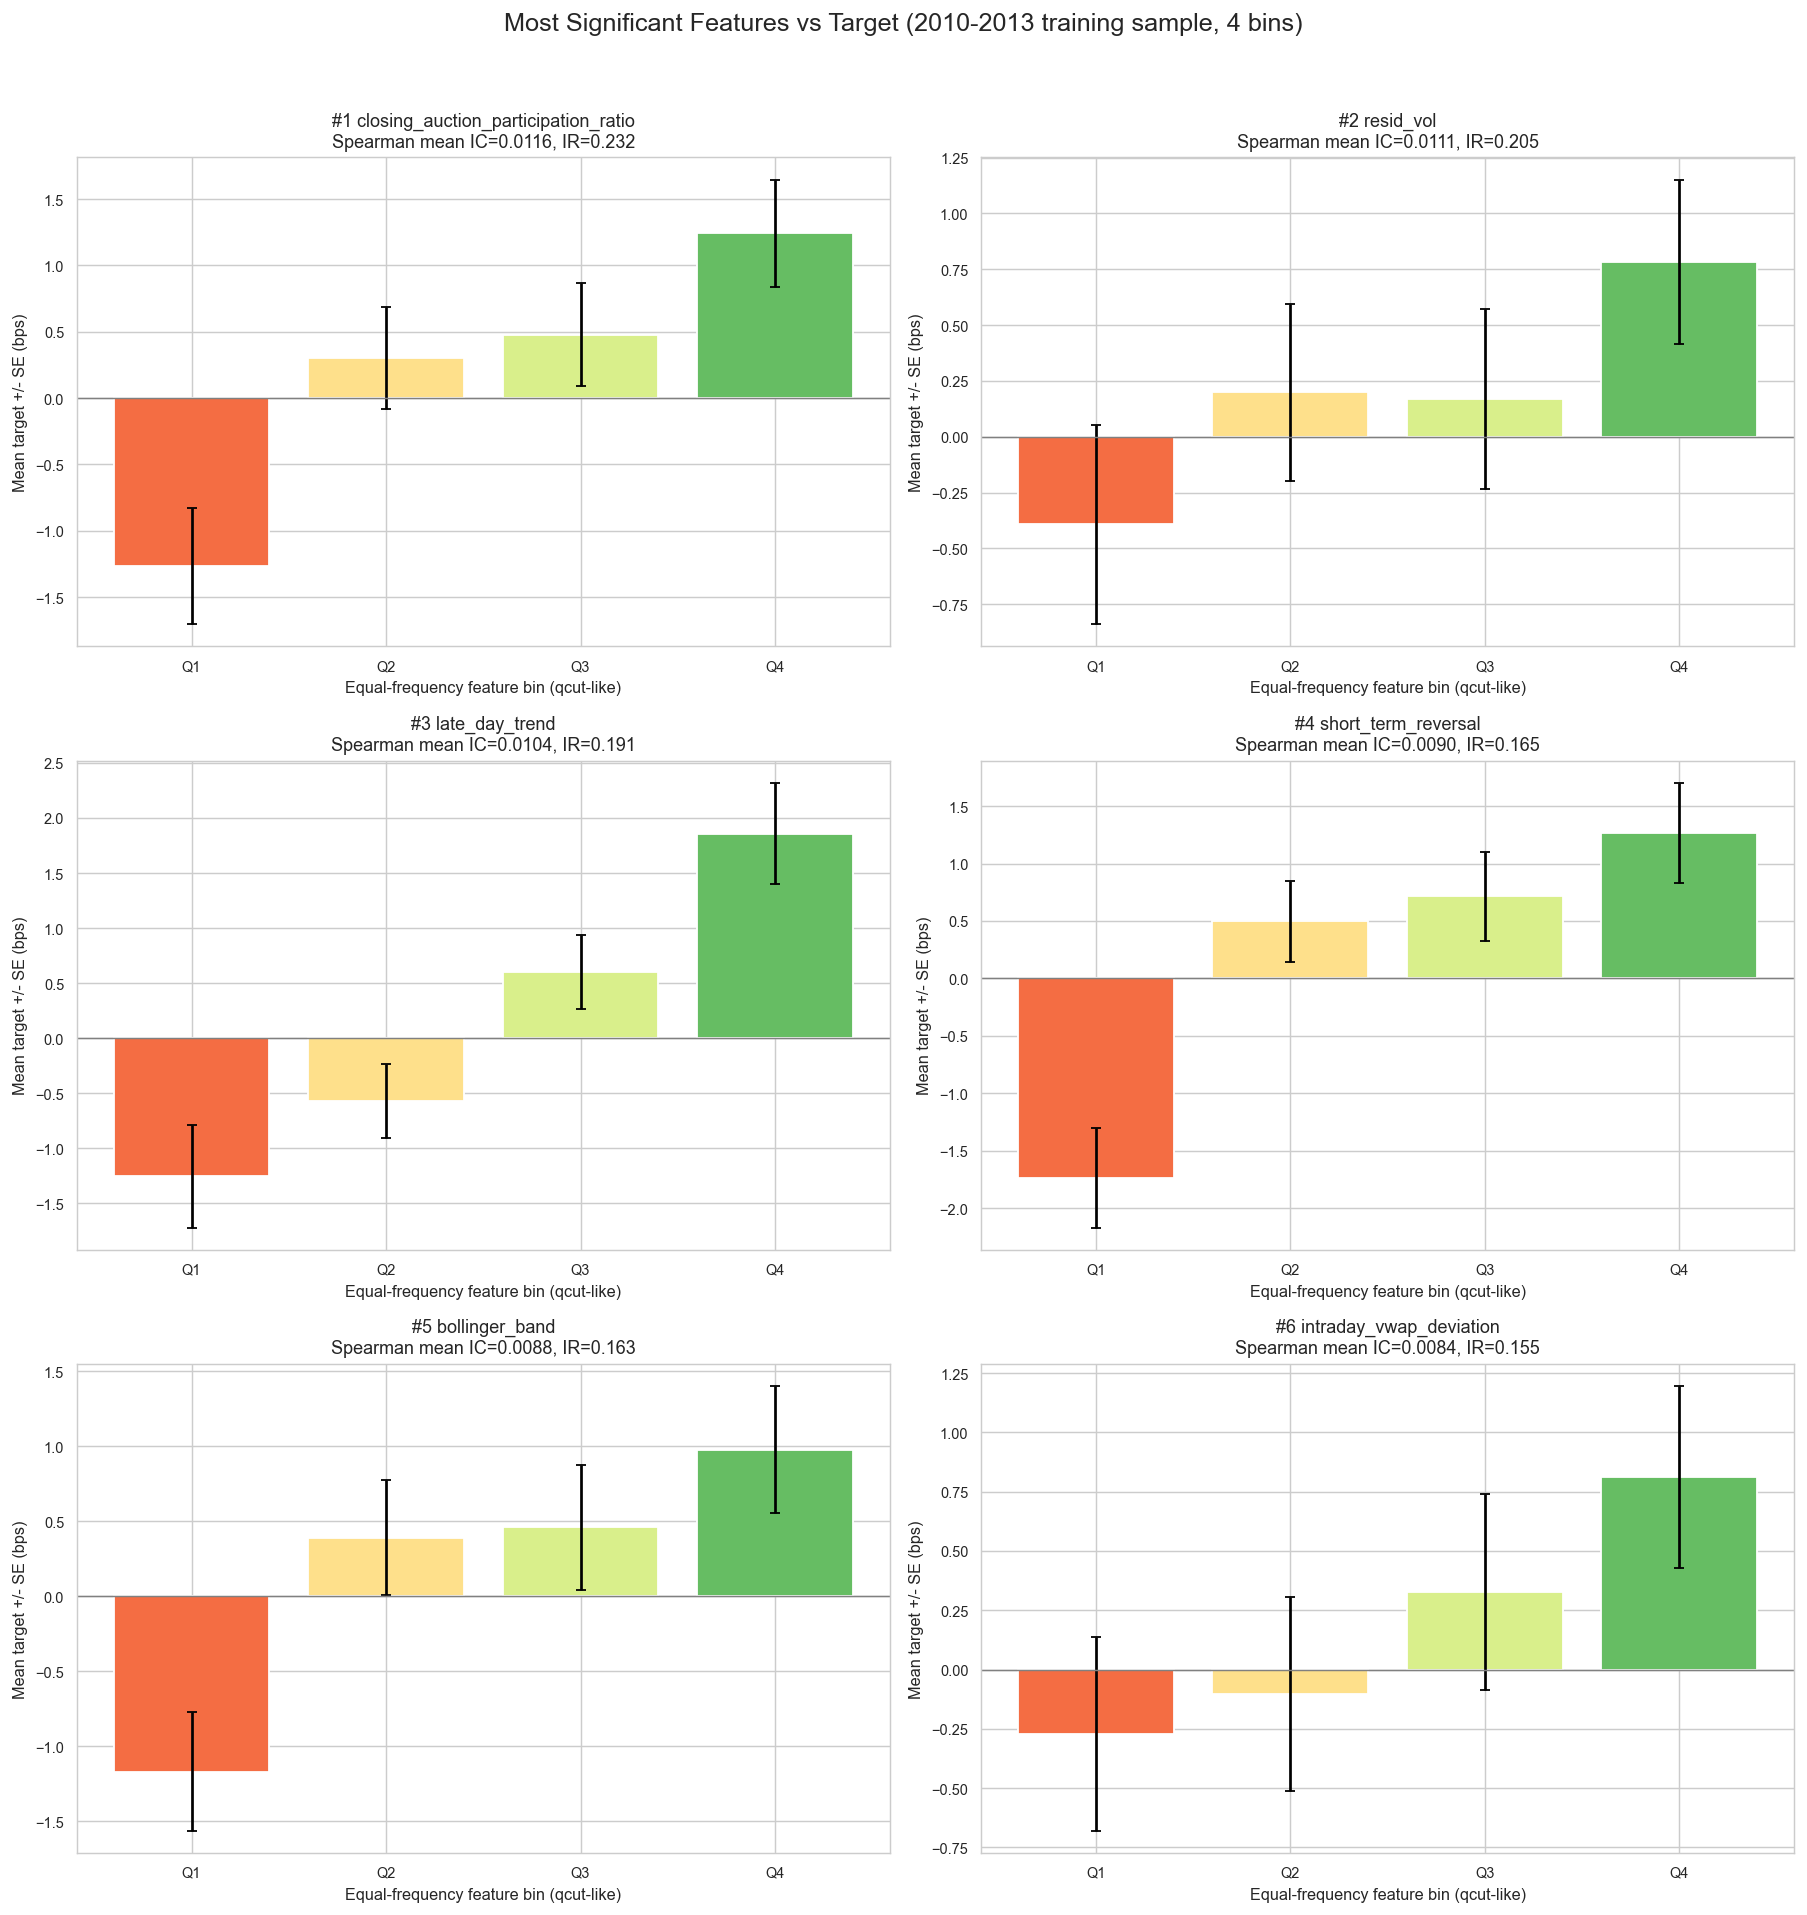

In [1]:
try:
    from whitepaper_notebook import render_feature_bin_figure
except ModuleNotFoundError:
    from submit.whitepaper_notebook import render_feature_bin_figure

feature_bin_report = render_feature_bin_figure()
feature_bin_report["figure"]


**Figure 7.1.** Feature-side significance proxy: top-ranked features vs. target using qcut-like equal-frequency **4-bin** plots on the 2010-2013 training sample.

![Top feature bin plots](figures/top_feature_bin_plots_train_4bins.png)


## 8. Model Fitting, Hyperparameter Tuning, and Selection

### 8.1 Data splitting strategy

All hyperparameter tuning used only **2010–2012** data (the first three years). 2013 was held out for walk-forward backtesting. 2014 was the final validation year, touched only after all hyperparameters were frozen. 2015 (`oos_data/`) was the true OOS year, used for final reporting only.

To avoid look-ahead bias in cross-validation on the 2010–2012 HP search set, we used a **Purged K-Fold CV** (López de Prado, 2018 Ch. 7) with 5 folds, `purge_days=1`, and `embargo_days=5`. This removes training rows whose labels overlap with validation dates, and excludes a five-day embargo buffer after each validation block.

### 8.2 Sample weights

No sample weights were applied during fitting. The `MDV_63` and `EST_VOL` fields are available in the daily panel for future use. A sensible default for a subsequent iteration would be $w_i \propto \sqrt{\mathrm{MDV}_{63,i}}$, which down-weights the most liquid names without fully excluding illiquid ones.

### 8.3 Feature normalization before modelling

Before any model sees the data, three normalization stages are applied in sequence:

1. **5-MAD clipping** — per feature, using bounds computed from 2010–2013 training data only.
2. **Stage-1 z-score** — subtract training mean, divide by training std (training-derived, applied to all splits).
3. **Cross-sectional rank normalization** — per-date rank → inverse-normal CDF transform, making the feature cross-section approximately $N(0,1)$ on each day. No stored parameters are needed for this step; it is applied to each date's cross-section independently.

### 8.4 Required models and hyperparameter search

#### Ridge Regression

- **Search grid:** $\alpha \in \{0.01, 0.1, 1, 10, 100, 1000, 10000\}$
- **Selection metric:** mean cross-sectional Spearman IC over 5 purged folds
- **Best $\alpha$:** 1000
- **Notes:** IC was nearly flat across $\alpha \geq 1$, indicating the normalized features make regularization strength secondary. Higher $\alpha$ was preferred for stability.

#### Random Forest Regressor

- **Search grid:** `n_estimators` ∈ {100, 200}, `max_depth` ∈ {3, 5}, `min_samples_leaf` ∈ {50, 100, 200} — 12 combinations × 5 folds = 60 fits
- **Best params:** `n_estimators=200, max_depth=5, min_samples_leaf=50, max_features=0.5`
- **Notes:** Shallow trees (depth 3–5) with large `min_samples_leaf` prevent individual trees from memorizing the noisy return signal. `max_features=0.5` adds diversity across trees.

#### XGBoost

- **Search grid:** `n_estimators` ∈ {100, 500}, `max_depth` ∈ {3, 5}, `learning_rate` ∈ {0.01, 0.05}, `reg_lambda` ∈ {0.1, 1.0, 10.0}, plus a time-decay weight sweep — 48 combinations × 5 folds = 240 fits
- **Best params:** `n_estimators=500, max_depth=3, learning_rate=0.01, reg_lambda=1.0`
- **Notes:** Very shallow trees with a low learning rate and many rounds gives the best IC. Heavy L2 (`reg_lambda`) is essential. Time-decay weighting (upweighting recent observations) did not consistently improve OOS IC.

#### MLP (sklearn `MLPRegressor`)

- **Search grid:** `hidden_layer_sizes` ∈ {(128,64), (256,128,64)}, `alpha` ∈ {1e-4, 1e-3}, `learning_rate_init` ∈ {1e-3, 5e-4} — 8 combinations × 5 folds = 40 fits
- **Best params:** `hidden_layer_sizes=(256,128,64), alpha=1e-4, learning_rate_init=1e-3`
- **Notes:** Signs of overfitting observed (val IC > OOS IC). This motivated the addition of the Residual MLP.

#### Residual MLP (PyTorch, custom architecture)

- **Architecture:** input projection → $N$ residual blocks (Linear → ReLU → Dropout → Linear + skip) → output head. No BatchNorm (removed to eliminate train/eval running-stats mismatch on OOS data).
- **Search grid:** `hidden` ∈ {128, 256}, `n_blocks` ∈ {2, 3}, `dropout` ∈ {0.2, 0.3} — 8 combinations × 5 folds = 40 fits
- **Training:** Adam optimizer, `weight_decay=1e-3`, `batch_size=4096`, manual `torch.randperm` mini-batching (no DataLoader). HP search uses IC-based early stopping; final training uses loss-based early stopping to avoid regime overfitting.
- **Best params:** `hidden=128, n_blocks=2, dropout=0.2`

### 8.5 Two ensemble combinations

After individual model evaluation, two diversity-weighted ensembles were formed. Diversity weights are $w_i \propto 1 / (1 + \bar{\rho}_i)$, where $\bar{\rho}_i$ is the mean pairwise absolute Spearman rank correlation of model $i$'s predictions with all other members. Models that produce more orthogonal signals receive higher weight.

- **Ens-3 (Div-Weighted):** Ridge + RF + XGB — the three most reliable base learners with the lowest inter-model correlation.
- **Ens-5 (Div-Weighted):** Ridge + RF + XGB + MLP + Residual MLP — full ensemble including both neural models.

## 9. Validation and OOS Results

### 9.1 Validation protocol

- **2014 (validation year):** Models trained on 2010–2013 with frozen hyperparameters. 2014 was never seen during feature research or HP tuning.
- **2015 (true OOS):** All five models retrained on the full 2010–2014 dataset (best HPs unchanged). 2015 features transformed with the same clip/normalization params derived from 2010–2013 — no look-ahead.
- **Metrics:** unweighted $R^2$, cross-sectional Spearman IC (overall and daily hit rate).

### 9.2 2014 Validation Results

Models trained on 2010–2013, evaluated on 2014. Hyperparameters were selected using Purged K-Fold CV on 2010–2012 only.

| Model | Best HPs | OOS R² | OOS IC | OOS Hit% |
|---|---|---|---|---|
| Ridge | α = 1000 | −0.0001 | +0.0155 | 61.6% |
| Random Forest | d=5, n=200, leaf=50 | +0.0000 | +0.0134 | 58.8% |
| XGBoost | d=3, n=500, lr=0.01, λ=1.0 | +0.0003 | +0.0169 | 60.4% |
| MLP | layers=(256,128,64), α=1e-4, lr=1e-3 | −0.0002 | +0.0108 | 58.0% |
| Residual MLP | hidden=128, blocks=2, dropout=0.2 | +0.0001 | +0.0190 | **65.3%** |
| **Ens-5 (Div-Weighted)** | w=(0.195, 0.201, 0.201, 0.199, 0.204) | +0.0001 | **+0.0179** | 62.0% |
| Ens-3 (Div-Weighted, Ridge+RF+XGB) | w=(0.340, 0.331, 0.329) | +0.0001 | +0.0173 | 60.4% |

**Key observations (2014):**
- Residual MLP achieved the highest IC (+0.0190) and hit rate (65.3%) among individual models on 2014, despite being the most complex — likely benefiting from the noise-robust architecture (no BatchNorm, loss-based early stopping against 2013 val).
- XGBoost was the second-strongest individual model by IC (+0.0169), with shallow trees (depth 3) + heavy L2 regularization proving most effective.
- Ridge's IC (+0.0155) was competitive with the tree-based models, indicating the normalized features carry a strong linear component.
- Ens-5 improved IC over all linear-model and tree-model baselines (+0.0179), confirming the diversity-weighting scheme reduces correlated prediction errors.
- All models produced positive mean daily IC (Hit% > 50%), indicating consistent directional signal across the validation year.

### 9.3 Inter-model prediction correlations (2014)

Pairwise absolute Spearman $|\rho|$ between model predictions on the 2014 OOS set:

|  | Ridge | RF | XGB | MLP | ResidMLP |
|---|---|---|---|---|---|
| **Ridge** | 1.000 | 0.735 | 0.754 | 0.878 | 0.831 |
| **RF** | 0.735 | 1.000 | 0.852 | 0.754 | 0.640 |
| **XGB** | 0.754 | 0.852 | 1.000 | 0.696 | 0.680 |
| **MLP** | 0.878 | 0.754 | 0.696 | 1.000 | 0.715 |
| **ResidMLP** | 0.831 | 0.640 | 0.680 | 0.715 | 1.000 |

ResidMLP has the lowest average correlation with other models (avg |ρ| = 0.717), earning it the highest diversity weight in Ens-5 (0.204). RF and XGB are highly correlated with each other (0.852), which is why Ens-3 (Ridge+RF+XGB) achieves similar IC to Ens-5 despite using fewer models.

### 9.4 2015 True OOS Results

All models retrained on the full 2010–2014 dataset. 2015 features built from `oos_data/` using training-derived transformation parameters only.

| Model | OOS R² | OOS IC | OOS Hit% |
|---|---|---|---|
| Ridge | −0.0000 | +0.0086 | 55.5% |
| Random Forest | +0.0002 | **+0.0103** | **59.5%** |
| XGBoost | −0.0003 | +0.0084 | 55.5% |
| MLP | +0.0000 | +0.0058 | 57.5% |
| Residual MLP | −0.0003 | +0.0049 | 54.3% |
| Ens-5 (Div-Weighted) | +0.0001 | +0.0086 | 55.5% |
| **Ens-3 (Div-Weighted, Ridge+RF+XGB)** | +0.0001 | +0.0092 | 58.7% |

**Key observations (2015):**
- All ICs dropped from 2014 → 2015, consistent with a regime shift (2015 saw elevated volatility / macro uncertainty). This is a realistic pattern in financial ML — signals that are stable within a regime often weaken across regime boundaries.
- RF was the strongest model in 2015 (IC=+0.0103, Hit%=59.5%), suggesting that its ensemble averaging provides more regime robustness than individual learners.
- Ens-3 (Ridge+RF+XGB) outperformed Ens-5 (+0.0092 vs +0.0086 IC), indicating the neural models added noise rather than signal in the 2015 regime — their higher 2014 performance did not transfer, and their lower inter-model diversity with the linear models was insufficient to offset this.
- XGB and ResidMLP showed negative $R^2$, driven by prediction magnitude errors, though their IC remained weakly positive. This separation between IC and $R^2$ is common in financial prediction: cross-sectional ranking can survive even when absolute scale is off.

### 9.5 Feature normalization applied to OOS data

The 2015 feature matrix was transformed in three steps using exclusively training-derived parameters:

1. **Clipping:** each feature clipped to `[clip_lo, clip_hi]` bounds from 2010–2013 training (`clip_params.joblib`).
2. **Z-score:** training mean and std from `norm_params.joblib` applied. No 2015 statistics used.
3. **Cross-sectional rank normalization:** per-date rank → $N(0,1)$ quantile on 2015 cross-sections only — no look-ahead.

## Appendix — Section 5.3 Visualizations

The assignment requires a per-year visualization suite. The feature-side plots are already implemented. Prediction-side plots will be added to `experimentation.ipynb` once the notebook run completes and the variables (`preds_2015`, `all_preds_2015`, `df_2015_norm`, etc.) are available in the live kernel.

| Required visualization | Status | Source |
|---|---|---|
| Monthly feature time series (mean, p1, p99, min, max) | ✅ Implemented | `render_monthly_feature_appendix()` — Figure A.1 below |
| Prediction histogram per year | 🔜 After notebook run | `experimentation.ipynb` — 2014 + 2015 OOS sections |
| Prediction bin plot per year (4 bins, mean actual return) | 🔜 After notebook run | `experimentation.ipynb` — OOS visualization cells |
| Drift plot per year (24h before → 48h after, 15-min intervals) | 🔜 After notebook run | `experimentation.ipynb` — requires intraday return merge |
| 30-day moving average of cross-sectional IC | 🔜 After notebook run | `experimentation.ipynb` — rolling IC plots |

**Figure A.1** below shows the monthly feature distribution (mean, 1st/99th percentiles, min, max) across all 18 enabled features for the full five-year sample. This is the complete implementation of the monthly time-series visualization required by Section 5.3.

Feature source: E:\Baruch\MLproject\output_submit_full
Rows loaded: 626,431
Saved monthly appendix figure to: E:\Baruch\MLproject\submit\figures\monthly_feature_distribution_all_features.png


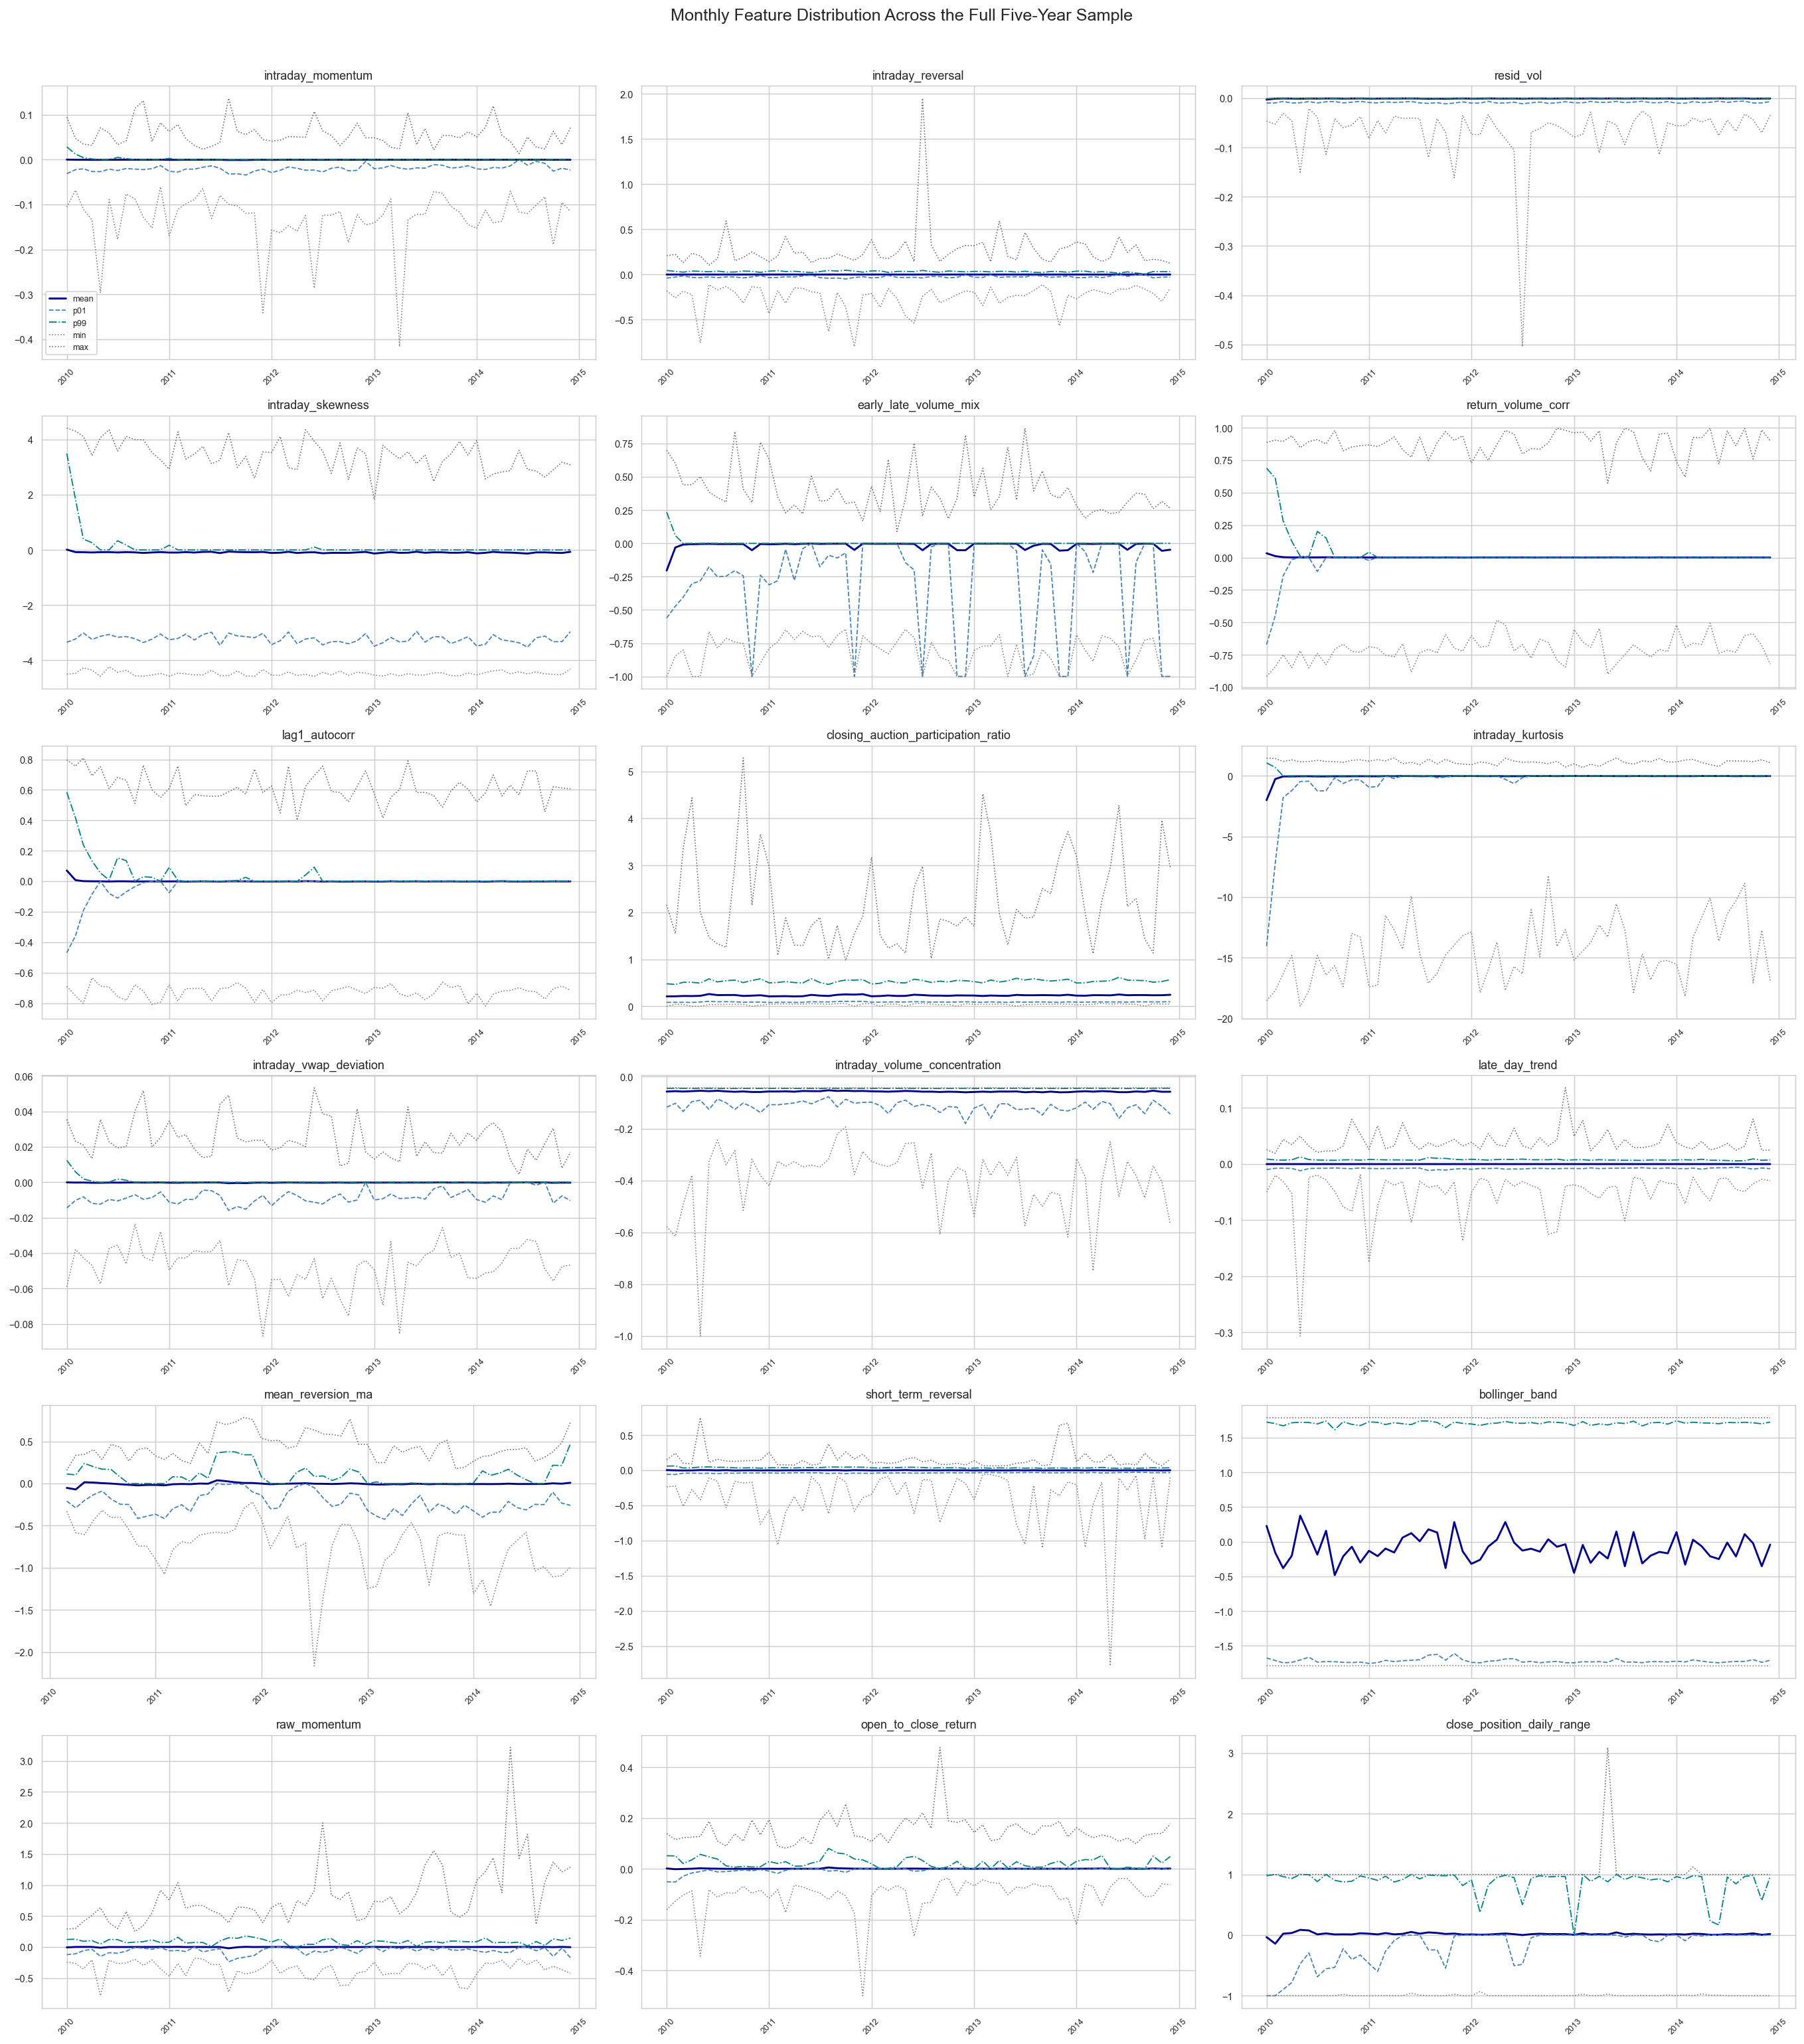

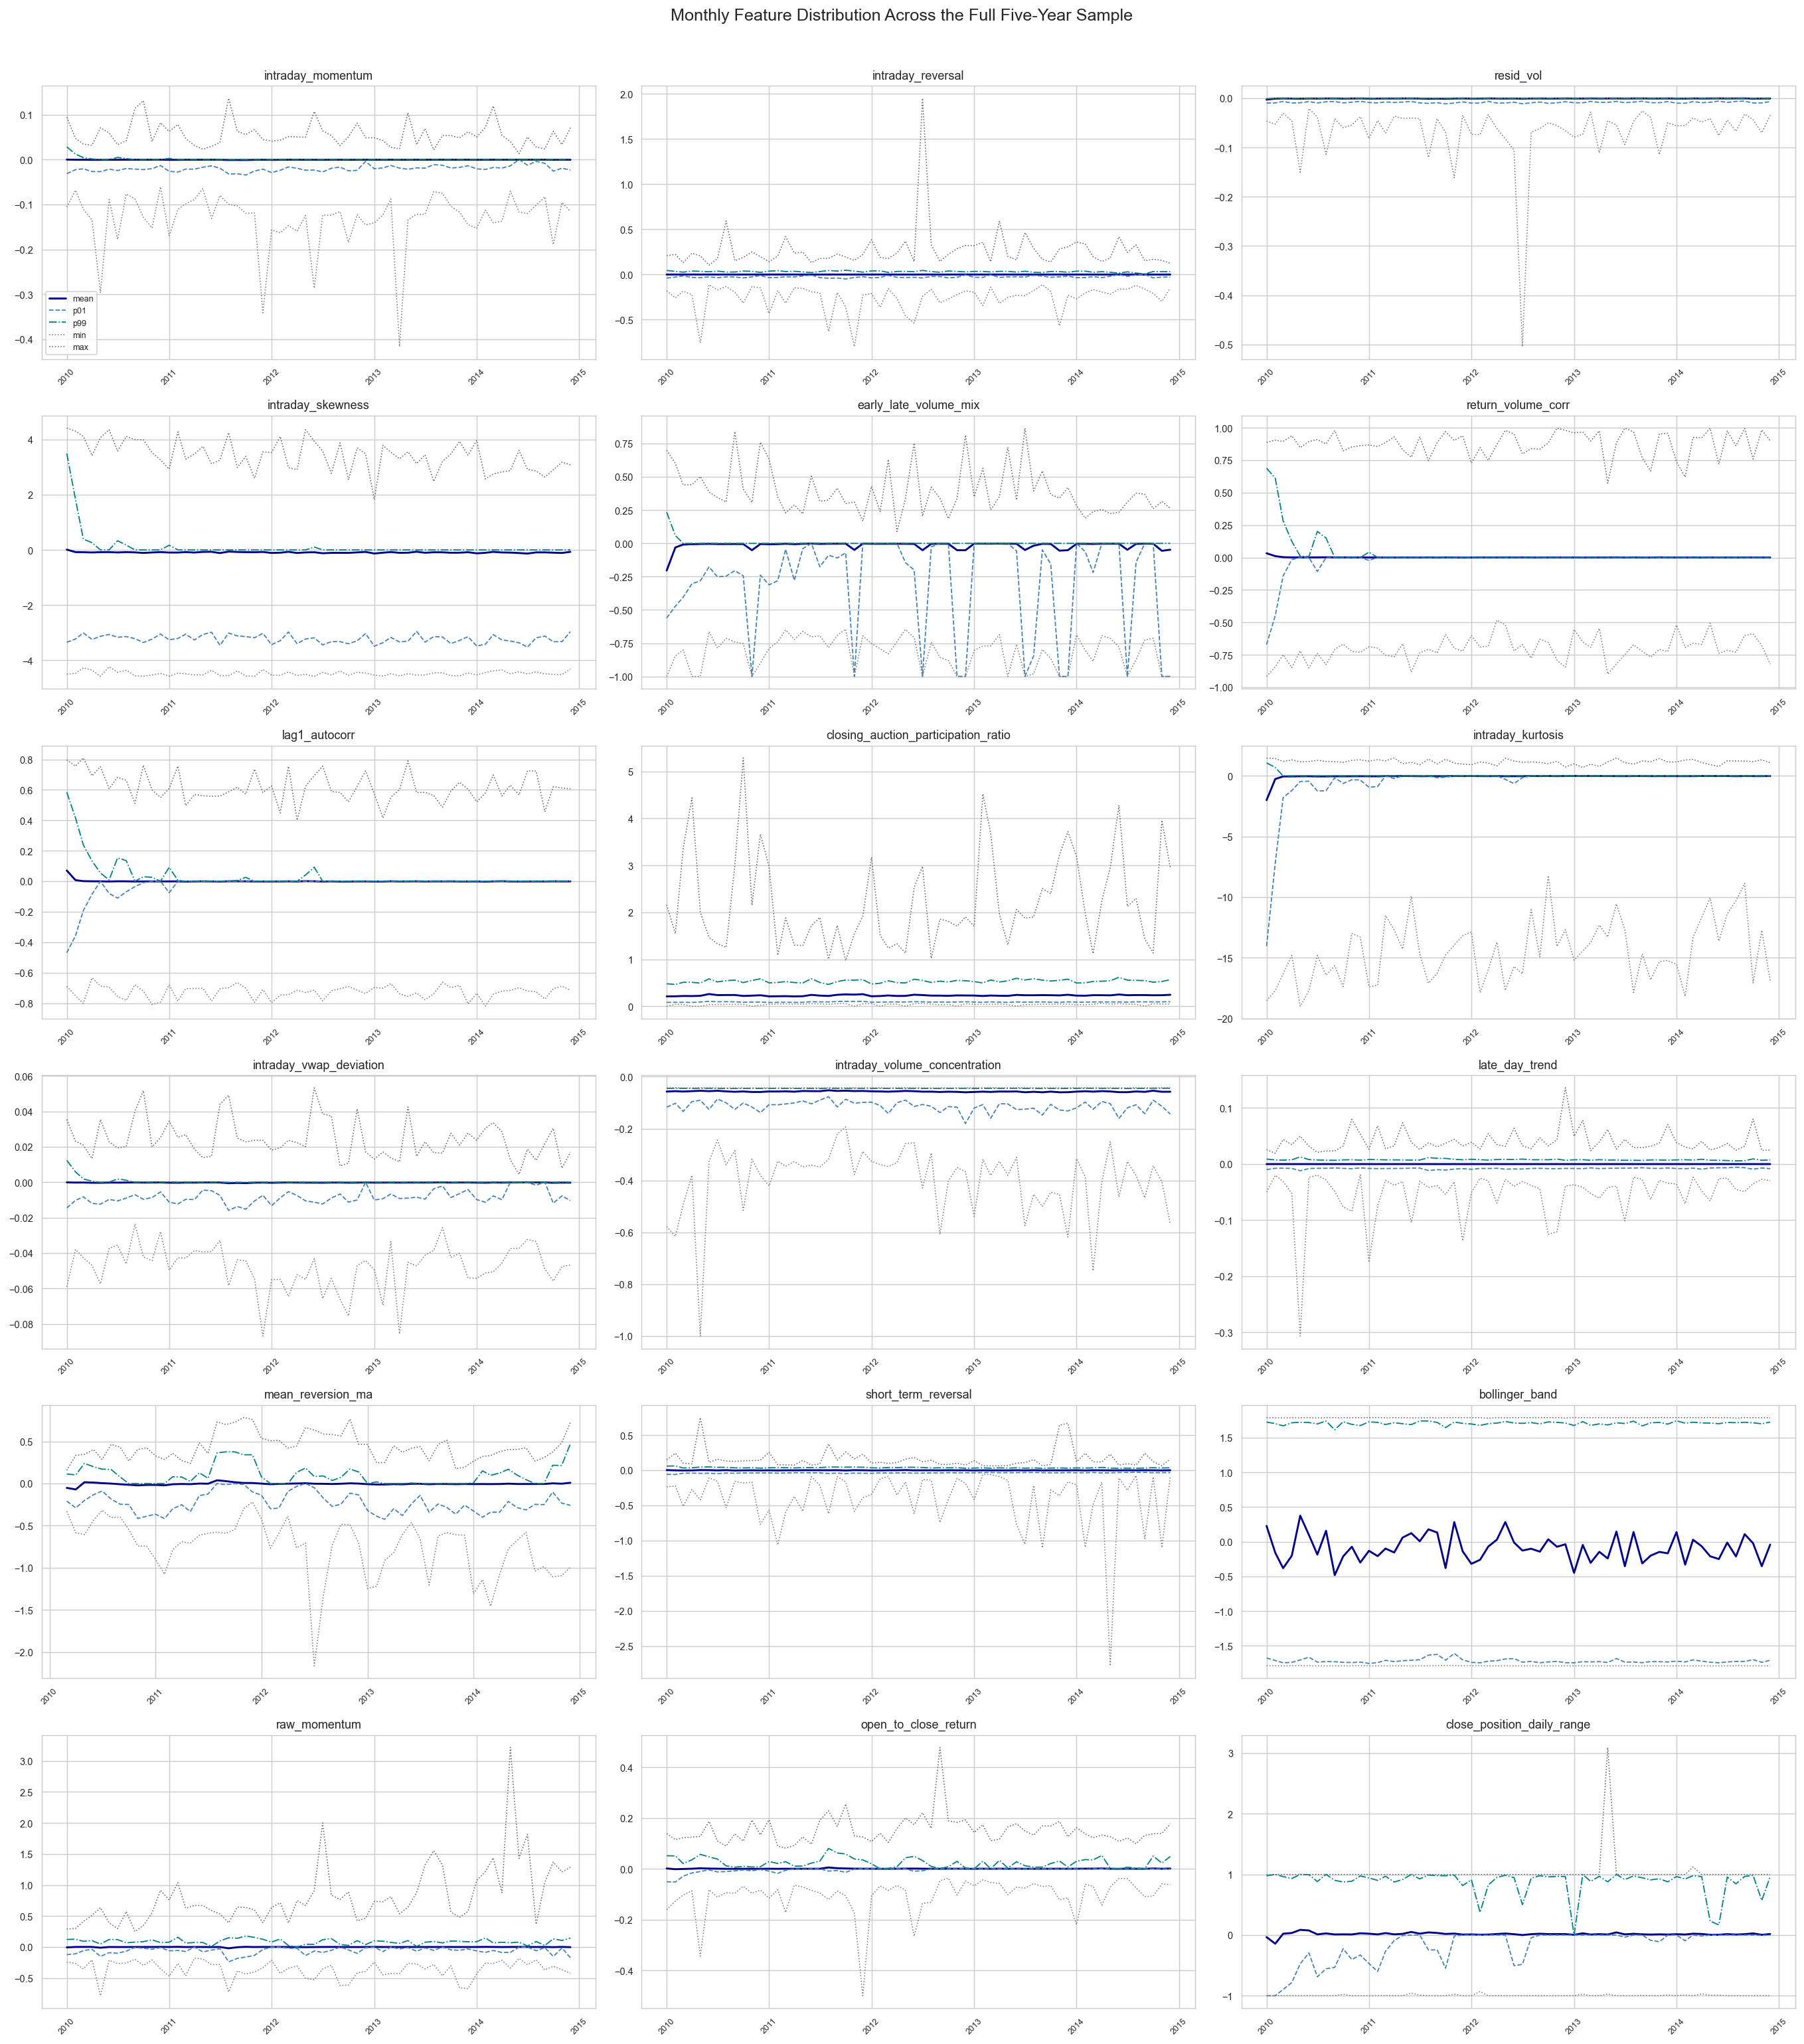

In [2]:
try:
    from whitepaper_notebook import render_monthly_feature_appendix
except ModuleNotFoundError:
    from submit.whitepaper_notebook import render_monthly_feature_appendix

monthly_feature_report = render_monthly_feature_appendix()
monthly_feature_report["figure"]


**Figure A.1.** Monthly feature distribution across the full five-year sample, showing the five required lines for each enabled feature: mean, 1st percentile, 99th percentile, min, and max.

![Monthly feature distributions](figures/monthly_feature_distribution_all_features.png)
